# <font size="7"> **Assignment-6**</font>
I hope this assignment will give you clarity on how mathematical models like **Multilayer Perceptrons (MLP)** can be made from scratch using **PyTorch** & can be used to solve complex, non-linear geometric problems **without relying on black-box libraries**.

---
# ⚫ **Mission Critical: The Exclusion Zone Protocol**

**Date:** Year 2142  
**Location:** Exoplanet *Kepler-186f*   **Clearance:** IITians

---

### **⚫ The Story**
Humanity has colonized the distant exoplanet *Kepler-186f*. While the surface is habitable, the planet's magnetic core is unstable. The **Global Defense Council (GDC)** has identified a dangerous phenomenon known as the **"Radiation Ring."**

Sensors indicate that the safe zones on the planet follow a peculiar geometry:
* ⚫ **The Core Zone:** Distance $< 2$ km from the colony center (Safe).
* ⚫ **The Outer Wilds:** Distance $> 4$ km from the colony center (Safe).
* ⚫ **The Dead Zone:** The region **between 2 km and 4 km** is flooded with lethal gamma radiation.

Your engineering team has deployed **3,000 sensor drones** across the colony to map this danger. Each drone reports its coordinates $(x, y)$ and a binary label:
* `1`: Radiation Detected (Dead Zone)
* `0`: Safe Zone

 **⚫ The Problem:** The sensors are cheap and prone to interference. Approximately **5%** of the drones are malfunctioning and reporting the wrong safety status (noise). The GDC mainframe is a legacy system that forbids the use of modern "Neural Libraries" (i.e., you cannot use `torch.nn` or `torch.optim`). You must build a **Multi-Layer Perceptron (MLP) from scratch** to filter out the noise and mathematically define the Exclusion Zone boundaries using **PyTorch**. ( Hint: You know this is a binary classification problem, which Loss function would you use?? )

---

### **⚫ Your Objective**

1.  **Initialize the System:** Use your **Group Number** as the random seed. This ensures your team works on a unique sensor distribution pattern.
2.  **Architect the Filter:** Construct a neural network with **3 hidden layers** (16 neurons each) to learn the non-linear "donut" shape of the Dead Zone.
3.  **Manual Calibration:** You cannot use auto-optimizers. You must manually calculate the gradients (Backpropagation) and update the system weights using **Gradient Descent**.
4.  **Verify Integrity:** Split your sensor data (70% training, 30% validation). Prove that your system doesn't just memorize the malfunctioning sensors (overfitting) but actually learns the geometric shape of the Dead Zone.

---

## ⚫ Engineering Constraints (Read Carefully)

**1. Restricted Modules**
*  **Forbidden:** You are strictly forbidden from importing `torch.nn` (Layers/Loss) or `torch.optim` (Optimizers).
*  **Allowed:** `import torch`, `import matplotlib.pyplot`, `import pandas`, `import numpy`, using `sklearn`.


**2. The Mechanics**
* **Forward Pass:** Must be implemented using raw matrix multiplication (`torch.matmul`) and bias addition.
* **Backward Pass:** You **MAY** use `loss.backward()` to compute gradients automatically (Autograd).
* **Optimization:** You **MUST** implement the weight updates manually (Stochastic Gradient Descent).
    > `w_new = w_old - learning_rate * w_old.grad`

**3. Loss Function**
Since `torch.nn` is banned, you must implement **Binary Cross Entropy** manually using basic tensor math.

$$Loss = -\frac{1}{N} \sum_{i=1}^{N} [y_i \cdot \log(\hat{y}_i) + (1-y_i) \cdot \log(1-\hat{y}_i)]$$

* **Note:** Ensure you handle the log of zero (numerical stability) or use `torch.clamp` to avoid `NaN` errors.

**4. Visual Proof:** Your final output must include a Decision Boundary Map showing the "Donut" shape.


---

### ⚫ **The GDC Dashboard (Required Output)**



The Global Defense Council requires visual confirmation that your system is stable before we can upload it to the drone fleet. You must generate a **3-Panel Heads-Up Display (HUD)** containing the following telemetry:

**1. System Error Trajectory (Loss Plot)**
* **Mission:** Plot the **Training Loss** (Blue) vs. **Validation Loss** (Orange) over all epochs.
* **Why:** We need to confirm that the system is actually learning and not just diverging (exploding gradients).

**2. Integrity Check (Accuracy Plot)**
* **Mission:** Plot the **Training Accuracy** vs. **Validation Accuracy**.
* **Why:** If Training Accuracy is high (95%) but Validation Accuracy is low (80%), you have failed to generalize. This is a sign of **Overfitting**—memorizing sensor noise instead of the Radiation Ring.

**3. Geospatial Threat Map (Decision Boundary)**
* **Mission:** Visualize the **Validation Set** on a 2D map.
* **Overlay:** Draw the neural network's **Decision Boundary** (the contours where confidence = 0.5).
* **Why:** The Commander needs to *see* the "Donut" shape. If your boundary looks like a jagged mess, the model is rejected.

---

In [13]:
import torch
import numpy as np
# ===========================================================
# PART 1: Data Generation (The Exclusion Zone)
# ===========================================================

# ⚠️ INSTRUCTION: Replace 1 with your actual Group Number
GROUP_NUMBER = 10

# Set seed for reproducibility
torch.manual_seed(GROUP_NUMBER)
np.random.seed(GROUP_NUMBER)

def generate_data(n_samples=3000):
    """
    Generates 3000 sensor readings for the Kepler-186f Exclusion Zone.
    Shape: Concentric circles (Donut).
    Logic:
      - Dead Zone (1): 2km < distance < 4km
      - Safe Zone (0): distance < 2km OR distance > 4km
    """
    # Generate random coordinates between -5 and 5 km
    X = (torch.rand(n_samples, 2) * 10) - 5

    # Calculate distance from center (radius)
    radius = torch.sqrt(X[:, 0]**2 + X[:, 1]**2)

    # Assign Labels: 1 if inside the Dead Zone, 0 otherwise
    y = ((radius > 2) & (radius < 4)).float().view(-1, 1)

    # Add 5% Noise (Malfunctioning Drones)
    n_noise = int(0.05 * n_samples)
    noise_indices = torch.randperm(n_samples)[:n_noise]
    y[noise_indices] = 1 - y[noise_indices] # Flip labels

    return X, y

# Generate the dataset
X_full, y_full = generate_data(3000)

print(f"Data Generated: {X_full.shape} samples.")
print(f"Target Generated: {y_full.shape} labels.")

Data Generated: torch.Size([3000, 2]) samples.
Target Generated: torch.Size([3000, 1]) labels.


Epoch 0 | Loss: 0.7733 | Train Acc: 0.3943 | Val Acc: 0.4000
Epoch 500 | Loss: 0.4532 | Train Acc: 0.8114 | Val Acc: 0.7900
Epoch 1000 | Loss: 0.3650 | Train Acc: 0.8967 | Val Acc: 0.8944
Epoch 1500 | Loss: 0.3170 | Train Acc: 0.9214 | Val Acc: 0.9144
Epoch 2000 | Loss: 0.3169 | Train Acc: 0.9062 | Val Acc: 0.9022
Epoch 2500 | Loss: 0.3056 | Train Acc: 0.9119 | Val Acc: 0.9133
Epoch 3000 | Loss: 0.2909 | Train Acc: 0.9181 | Val Acc: 0.9233
Epoch 3500 | Loss: 0.2797 | Train Acc: 0.9167 | Val Acc: 0.9222
Epoch 4000 | Loss: 0.2717 | Train Acc: 0.9143 | Val Acc: 0.9222
Epoch 4500 | Loss: 0.2669 | Train Acc: 0.9148 | Val Acc: 0.9222
Epoch 5000 | Loss: 0.2594 | Train Acc: 0.9181 | Val Acc: 0.9267
Epoch 5500 | Loss: 0.2549 | Train Acc: 0.9190 | Val Acc: 0.9267


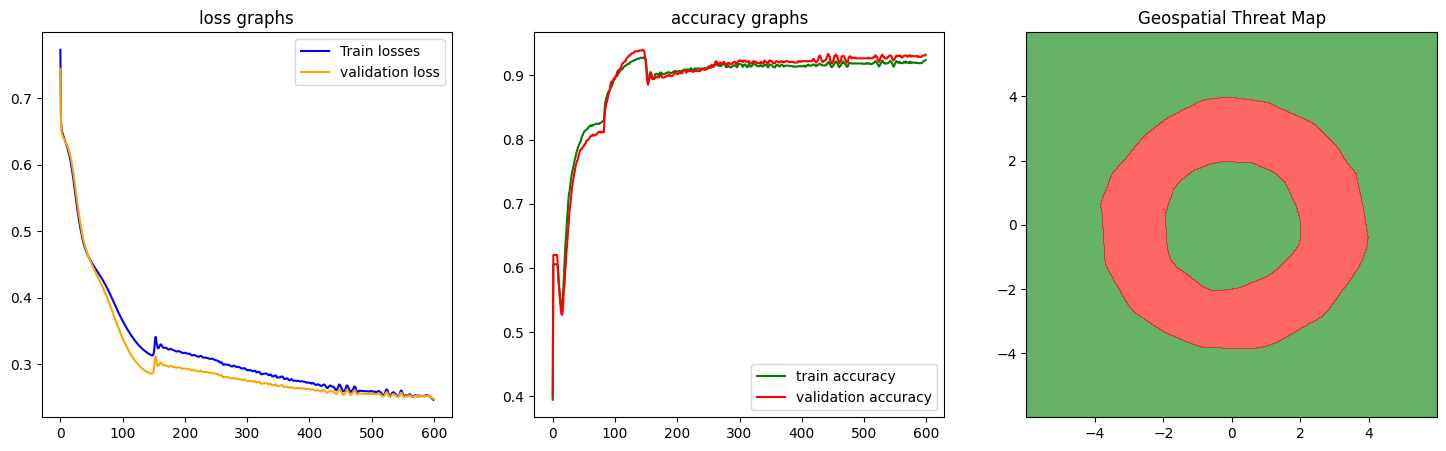

In [14]:
# ==============================================================================
# Code from here. Best of luckk :)
# ==============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(10)
np.random.seed(10)
train_size=int(0.7*3000)
X_train=X_full[:train_size]
y_train=y_full[:train_size]
X_val=X_full[train_size:]
y_val=y_full[train_size:]
input_dim=2
hidden_dim=16
output_dim=1
#intializing weights and bais  
scale_in=np.sqrt(2.0/input_dim)
#weights and bais for 1st layer
W_1=(torch.randn(hidden_dim,input_dim)*scale_in).requires_grad_(True)
b_1=torch.zeros(size=(hidden_dim,1),requires_grad=True)
#weights and bais for 2nd layer
scale_hidden=np.sqrt(2/hidden_dim)
W_2=(torch.randn(hidden_dim,hidden_dim)*scale_hidden).requires_grad_(True)
b_2=torch.zeros(size=(hidden_dim,1),requires_grad=True)
#weights and bais for 3rd layer 
W_3=(torch.randn(hidden_dim,hidden_dim)*scale_hidden).requires_grad_(True)
b_3=torch.zeros(size=(hidden_dim,1),requires_grad=True)
#weights and bais for output layer
W_4=(torch.randn(output_dim,hidden_dim)*scale_hidden).requires_grad_(True)
b_4=torch.zeros(size=(output_dim,1),requires_grad=True)
#final parameters 
parameters=[W_1,b_1,W_2,b_2,W_3,b_3,W_4,b_4]
train_loss=[]
val_loss=[]
train_acc=[]
val_acc=[]
#constructing the model
X_train_tr = X_train.T / 5.0
y_train_tr = y_train.T
X_val_tr = X_val.T / 5.0
y_val_tr = y_val.T
epochs=6000
train_rate=0.1
for ep in range(epochs):
    #1st layer
    z_1=torch.matmul(W_1,X_train_tr)+b_1
    a_1=torch.relu(z_1)
    #2nd layer
    z_2=torch.matmul(W_2,a_1)+b_2
    a_2=torch.relu(z_2)
    #3rd layer
    z_3=torch.matmul(W_3,a_2)+b_3
    a_3=torch.relu(z_3)
    #ouput layer
    z_4=torch.matmul(W_4,a_3)+b_4
    y_hat=torch.sigmoid(z_4)
    y_hat_safe=torch.clamp(y_hat,1e-6,1-(1e-6))
    #calculation of loss 
    loss= -torch.mean(y_train_tr * torch.log(y_hat_safe) + (1 - y_train_tr) * torch.log(1 - y_hat_safe))
    # back propagation
    loss.backward()
    with torch.no_grad():
        for p in  parameters:
            p -= (train_rate) * p.grad
            p.grad.zero_()
    #Validation and Accuracy
    if ep % 10 == 0 :
        with torch.no_grad():
            v_z_1=torch.matmul(W_1,X_val_tr)+b_1
            v_a_1=torch.relu(v_z_1)
            v_z_2=torch.matmul(W_2,v_a_1)+b_2
            v_a_2=torch.relu(v_z_2)
            v_z_3=torch.matmul(W_3,v_a_2)+b_3
            v_a_3=torch.relu(v_z_3)
            v_z_4=torch.matmul(W_4,v_a_3)+b_4
            v_y_hat=torch.sigmoid(v_z_4)
            v_y_hat_safe=torch.clamp(v_y_hat,1e-6,1-(1e-6))
            v_loss= -torch.mean(y_val_tr * torch.log(v_y_hat_safe) + (1 - y_val_tr) * torch.log(1 - v_y_hat_safe))
            train_loss.append(loss.item())
            val_loss.append(v_loss.item())
            tr_acc=((((y_hat_safe>0.5).float())==y_train_tr).float()).mean()
            v_acc=((((v_y_hat_safe>0.5).float())==y_val_tr).float()).mean()
            train_acc.append(tr_acc.item())
            val_acc.append(v_acc.item())
    if ep % 500 == 0:
         print(f"Epoch {ep} | Loss: {loss.item():.4f} | Train Acc: {tr_acc.item():.4f} | Val Acc: {v_acc.item():.4f}")
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.plot(train_loss,label='Train losses',color='blue')
plt.plot(val_loss,label='validation loss',color='orange')
plt.title('loss graphs')
plt.legend()
plt.subplot(1,3,2)
plt.plot(train_acc,label='train accuracy',color='green')
plt.plot(val_acc,label='validation accuracy',color='red')
plt.title('accuracy graphs')
plt.legend()
#creating the donut shape 
x_min, x_max = X_full[:, 0].min() - 1, X_full[:, 0].max() + 1
y_min, y_max = X_full[:, 1].min() - 1, X_full[:, 1].max() + 1
plt.subplot(1,3,3)
xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 50), 
    torch.linspace(y_min, y_max, 50), 
    indexing='ij' 
)
grid = torch.cat((xx.reshape(-1, 1), yy.reshape(-1, 1)), 1).T
grid_norm=grid/5.0
with torch.no_grad():
    # Forward pass on grid
    g_z1 = torch.matmul( W_1,grid_norm) + b_1
    g_a1 = torch.relu(g_z1)
    g_z2 = torch.matmul( W_2,g_a1) + b_2
    g_a2 = torch.relu(g_z2)
    g_z3 = torch.matmul( W_3,g_a2) + b_3
    g_a3 = torch.relu(g_z3)
    g_z4 = torch.matmul(W_4,g_a3) + b_4
    g_out = torch.sigmoid(g_z4).reshape(xx.shape)
plt.contourf(xx, yy, g_out, levels=[0, 0.5, 1], alpha=0.6, colors=['green', 'red'])
plt.title("Geospatial Threat Map")
plt.show()